# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:

# cantidad de nulos para users
print(users.isna().sum())
print()
print(users.isna().mean())



user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  
Para **users** existen valores faltantes en las columnas **city** y **churn_date**. En el caso de **city** existen 469 nulos, lo que equivale a un   11.72%, mientras que para **churn_date** la cifra es de 3534, esto equivale al 88.35%.

Para **usage** existen valores faltantes en las columnas **date**, **duration** y **length**. En el caso de **date** hablamos de 50 nulos, equivalentes a 0.125%, para **duration** 22076 nulos equivalentes a 55.19% y para lenght 17896 nulos equivalentes a un 44.74%.

  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Dataset users**

**city**: si la variable es importante para segmentación geográfica, conviene imputar (por ejemplo, con la ciudad más frecuente si el contexto lo permite) o crear una categoría adicional como “Desconocida”. No recomendaría eliminar registros, ya que implicaría perder casi 12% de los usuarios.

**churn_date**: el porcentaje es muy alto, pero esos nulos significan que el usuario no ha cancelado el servicio. Es decir, el nulo representa que el usuario sigue activo. Puede conservarse tal cual o convertirla en una variable binaria (churn = 1 si tiene fecha, 0 si es nulo).

**Dataset usage**

**date**: el porcentaje es mínimo. Se pueden eliminar esos registros sin afectar el análisis.

**duration**: más de la mitad de los datos están ausentes. Esto es crítico. Puede indicar que solo ciertos tipos de eventos tienen duración. Antes de imputar, verificar si los nulos dependen del tipo de evento (por ejemplo, texto vs llamada).Si el nulo significa “no aplica”, no imputar. Si debería existir valor, evaluar si la variable es suficientemente confiable para análisis.

**length**: alto porcentaje de faltantes, probablemente asociado al tipo de registro. Se recomienda verificar si solo aplica a cierto tipo de evento. No imputar automáticamente sin entender el patrón. Si el nulo significa “no aplica”, conservarlo como tal.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users

columnas_numericas_users = ('user_id', 'age')

for col in columnas_numericas_users:
    print(f"\n=== Análisis de {col} ===")
    print(users[col].describe())




=== Análisis de user_id ===
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

=== Análisis de age ===
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


- La columna **user_id** cuenta con 4000 registros sin valores faltantes y presenta un rango de 10000 a 13999. La media y la mediana coinciden exactamente en 11999.5, lo que indica una distribución completamente simétrica y uniforme. La desviación estándar es moderada y coherente con una numeración consecutiva. En general, esta variable funciona únicamente como identificador y no aporta valor analítico más allá de distinguir a cada usuario.
  
- La columna **age** también contiene 4000 registros; sin embargo, muestra una anomalía importante. Aunque el máximo (79 años) es razonable, el valor mínimo es -999, lo cual es imposible como edad y sugiere la presencia de sentinels para datos faltantes. Este valor distorsiona significativamente la media (33.74) y genera una desviación estándar extremadamente alta (123.23), además de provocar una diferencia notable entre media y mediana (47). Por lo tanto, es necesario limpiar la variable antes de realizar cualquier análisis interpretativo.

In [13]:
# explorar columnas numéricas de usage

columnas_numericas_usage = ('id', 'user_id', 'duration', 'length')

for col in columnas_numericas_usage:
    print(f"\n=== Análisis de {col} ===")
    print(usage[col].describe())
    


=== Análisis de id ===
count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

=== Análisis de user_id ===
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

=== Análisis de duration ===
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64

=== Análisis de length ===
count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64


- La columna **id** contiene 40,000 registros con valores consecutivos de 1 a 40,000. La media y la mediana coinciden exactamente, lo que refleja una distribución perfectamente uniforme. Funciona únicamente como identificador y no tiene valor analítico adicional.
  
- La columna **user_id** también presenta 40,000 registros, con valores entre 10,000 y 13,999. La media y la mediana son muy similares, lo que indica una distribución equilibrada dentro de un rango definido. Representa la asociación de registros a distintos usuarios, más que una variable de análisis numérico.

- En **duration** se observan 17,924 registros, evidenciando datos faltantes. La media es mayor que la mediana y el valor máximo (120) es muy superior al tercer cuartil, lo que indica asimetría positiva y posible presencia de valores atípicos. Además, el valor mínimo de 0 podría representar registros sin duración válida.

- **length** cuenta con 22,104 registros y muestra una media y mediana cercanas, aunque el valor máximo (1,490) es considerablemente alto frente al tercer cuartil, lo que sugiere valores extremos y alta dispersión en los datos.




In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\n=== Análisis de {col} ===")
    print(users[col].describe())







=== Análisis de city ===
count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

=== Análisis de plan ===
count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object


- La columna **city** cuenta con 3,531 registros no nulos y presenta 7 ciudades distintas. La ciudad más frecuente es Bogotá, con 808 registros, lo que indica una mayor concentración de usuarios en esa ubicación. También se observa la existencia de valores faltantes, ya que el total es menor al número general de observaciones (4000), por lo que sería conveniente revisar esos datos antes de un análisis más profundo.
  
- La columna **plan** contiene 4,000 registros completos y solo dos categorías distintas. El plan más común es “Basico”, con 2,595 usuarios, lo que muestra una clara preferencia por esta opción frente a la otra disponible. La variable está completa y no presenta valores faltantes, por lo que es adecuada para análisis comparativos entre planes.


In [15]:
# explorar columna categórica de usage
print('Análisis de type')
print(usage['type'].describe())

Análisis de type
count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna **type** tiene 40,000 registros completos y solo dos categorías. La más frecuente es “text” con 22,092 casos, lo que indica que predomina sobre la otra categoría. No presenta valores faltantes y es adecuada para análisis comparativos.



---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
El valor inválido o sentinel se identificó en la columna **age** del dataset **users**, donde aparece el valor -999, que es imposible como edad real. Este valor está afectando la media y generando una desviación estándar exageradamente alta, distorsionando la interpretación de la variable.

- ¿Qué acción tomarías?
La acción recomendable sería reemplazar -999 por valores nulos (NaN) para tratarlo como dato faltante. Posteriormente, se podría decidir entre eliminar esos registros o imputar la edad (por ejemplo, con la mediana), dependiendo del objetivo del análisis.


**OBSERVACIONES ADICIONALES**

- **duration**

**Diagnóstico:** Tiene valores faltantes (count menor al total) y muestra fuerte asimetría positiva, con un máximo (120) muy superior al tercer cuartil. Además, el valor 0 podría representar registros inválidos o eventos sin duración real.
**Recomendación**: Verificar el significado de los valores 0 y revisar los valores extremos. Si son errores, corregir o eliminar; si son válidos, utilizar medidas robustas (mediana, rango intercuartílico) para el análisis.

- **length**

**Diagnóstico:** Presenta datos faltantes y valores extremos importantes (máximo de 1,490 frente a un tercer cuartil de 64), lo que genera alta dispersión y posible sesgo en la media.
**Recomendación:** Analizar los valores atípicos para confirmar si son errores de captura. En caso de ser válidos, considerar transformaciones (como logaritmo) o emplear estadísticas robustas para evitar distorsiones en el análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['year'] = users['reg_date'].dt.year
print(users['year'].unique())


[2022 2026 2023 2024]


En `reg_date` se identificó una inconsistencia en el campo de año de registro: aunque 2022, 2023 y 2024 son valores coherentes con el periodo de análisis, aparece también 2026, un año futuro respecto al contexto actual (2024). Esto sugiere un posible problema de calidad de datos, probablemente asociado a errores de captura o validación, por lo que se recomienda revisar y depurar dichos registros para asegurar la confiabilidad del análisis.

In [19]:
# Revisar los años presentes en `date` de usage

usage['year'] = usage['date'].dt.year
print(usage['year'].unique())


[2024.   nan]


En `date` se identificó que el campo presenta valores correspondientes a 2024, lo cual es coherente con los datos analizados, pero también existen valores NaN, que indican fechas faltantes o inválidas. Los NaN representan solo el 0.125% de los datos (50 de 40,000), por lo tanto eliminar esas filas es la opción más práctica y eficiente.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  El año 2026 no tiene sentido, puesto que el contexto del análisis es el 2024. También aparecen registros de los años 2022 y 2023. En el dataset usage existen entradas solo del año 2024 y NaN.
- ¿Qué harías con ellas?
  Se recomienda revisar y depurar dichos registros para asegurar la confiabilidad del análisis. Los NaN representan solo el 0.125% de los datos (50 de 40,000), por lo tanto eliminar esas filas es la opción más práctica y eficiente. 
  

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace( -999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)


# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Ver todos los valores únicos después de limpieza  (incluyendo NA)
print("Valores únicos en city post-limpieza:")
print(users['city'].value_counts(dropna=False))

Valores únicos en city post-limpieza:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [23]:
# Marcar fechas futuras como NA para reg_date

users.loc[users['reg_date'] > '2024-12-31', 'reg_date'] = pd.NaT



# Verificar cambios
users['reg_date'].describe()



count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())




type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Se observa un patrón estructural claro entre las variables duration y length según el tipo de registro. Para los registros tipo call, la variable duration no presenta valores nulos, mientras que length es nula en el 99.93% de los casos. En contraste, para los registros tipo text, length no presenta valores faltantes y duration es nula en el 99.93% de los casos. Este comportamiento es consistente con la naturaleza de cada servicio, ya que las llamadas poseen duración pero no longitud en caracteres, mientras que los mensajes de texto poseen longitud pero no duración, lo que indica coherencia estructural en el modelo de datos y no un problema de calidad.

Ambos casos se clasifican como valores faltantes tipo MAR (Missing At Random). En consecuencia, no se considera necesario imputarlos y se mantienen como nulos para preservar la coherencia del modelo de datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # contar mensajes
    'is_call': 'sum',      # contar llamadas
    'duration': 'sum'      # sumar minutos
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas, ''
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes', 'is_call': 'cant_llamadas', 'duration': 'cant_minutos_llamada'})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 0 to 3999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               4000 non-null   int64         
 1   first_name            4000 non-null   object        
 2   last_name             4000 non-null   object        
 3   age                   4000 non-null   float64       
 4   city                  3435 non-null   object        
 5   reg_date              3960 non-null   datetime64[ns]
 6   plan                  4000 non-null   object        
 7   churn_date            466 non-null    object        
 8   year                  4000 non-null   int64         
 9   cant_mensajes         3999 non-null   float64       
 10  cant_llamadas         3999 non-null   float64       
 11  cant_minutos_llamada  3999 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 406.2+ K

In [30]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ('age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada')

for col in columnas_numericas:
    print(f"\n=== Análisis de {col} ===")
    print(user_profile[col].describe())



=== Análisis de age ===
count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

=== Análisis de cant_mensajes ===
count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64

=== Análisis de cant_llamadas ===
count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64

=== Análisis de cant_minutos_llamada ===
count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64


In [31]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

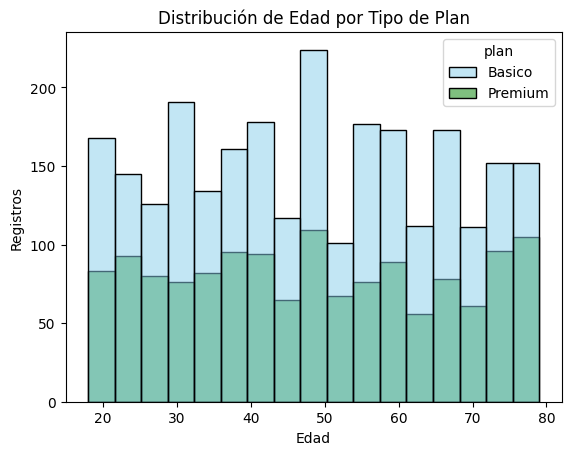

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(x=user_profile['age'], hue=user_profile['plan'], palette=['skyblue','green'])

plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Registros')
plt.show()

💡Insights: 
- La distribución de edades muestra que ambos planes presentan usuarios en un rango amplio, aproximadamente entre 18 y 80 años, aunque la mayor concentración se encuentra entre los 30 y 60 años. En casi todos los rangos de edad el plan Básico registra más usuarios que el Premium, lo que sugiere una mayor adopción general de este plan. Sin embargo, la forma de ambas distribuciones es similar, lo que indica que la edad no parece ser un factor determinante en la elección del tipo de plan, sino que ambos son utilizados por perfiles de edad relativamente parecidos.

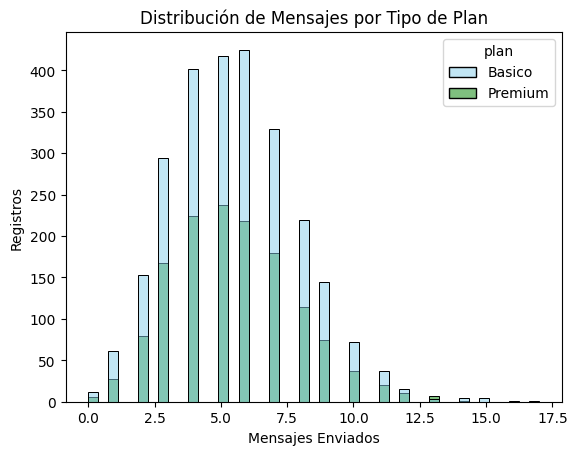

In [33]:
# Histograma para visualizar la cant_mensajes
sns.histplot(x=user_profile['cant_mensajes'], hue=user_profile['plan'], palette=['skyblue','green'])

plt.title('Distribución de Mensajes por Tipo de Plan')
plt.xlabel('Mensajes Enviados')
plt.ylabel('Registros')
plt.show()


💡Insights: 
- La distribución de mensajes enviados muestra un patrón similar entre ambos tipos de plan, con una mayor concentración de registros alrededor de 4 a 7 mensajes, lo que indica que la mayoría de los usuarios envía una cantidad moderada de mensajes. El plan Básico presenta un mayor número de registros en casi todos los rangos, lo que sugiere una base de usuarios más amplia. La forma de la distribución es ligeramente asimétrica hacia la derecha, ya que existen algunos usuarios que envían una cantidad mayor de mensajes (valores altos), aunque estos casos son menos frecuentes. Esto indica que, aunque el comportamiento típico es enviar pocos mensajes, existe una pequeña proporción de usuarios con un uso más intensivo.

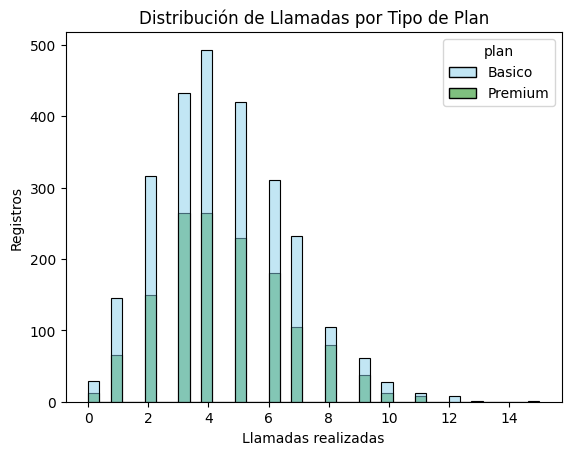

In [34]:
# Histograma para visualizar la cant_llamadas
sns.histplot(x=user_profile['cant_llamadas'], hue=user_profile['plan'], palette=['skyblue','green'])

plt.title('Distribución de Llamadas por Tipo de Plan')
plt.xlabel('Llamadas realizadas')
plt.ylabel('Registros')
plt.show()

💡Insights: 
- La distribución de llamadas realizadas muestra que la mayor concentración de usuarios se encuentra entre 3 y 6 llamadas, lo que indica que la mayoría mantiene un nivel moderado de uso de este servicio. Al igual que en otras métricas, el plan Básico presenta más registros en casi todos los rangos, reflejando una base de usuarios más amplia. La distribución es ligeramente asimétrica hacia la derecha, ya que existen algunos usuarios que realizan un número mayor de llamadas (por encima de 8–10), aunque estos casos son menos frecuentes. En general, ambos planes presentan un patrón de uso muy similar, lo que sugiere que el tipo de plan no genera grandes diferencias en la cantidad de llamadas realizadas.

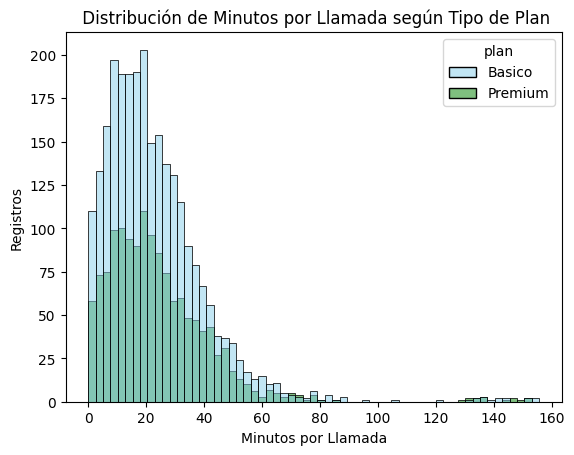

In [35]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(x=user_profile['cant_minutos_llamada'], hue=user_profile['plan'], palette=['skyblue','green'])

plt.title(' Distribución de Minutos por Llamada según Tipo de Plan')
plt.xlabel('Minutos por Llamada')
plt.ylabel('Registros')
plt.show()


💡Insights: 
- La distribución de minutos por llamada muestra que la mayoría de las llamadas se concentra en duraciones relativamente cortas, principalmente entre 5 y 30 minutos. La distribución presenta una asimetría positiva (sesgo a la derecha), ya que existe una cola larga de llamadas de mayor duración, aunque estos casos son poco frecuentes. El plan Básico registra más observaciones en la mayoría de los intervalos, lo que refleja una base de usuarios mayor, mientras que el plan Premium sigue un patrón muy similar de comportamiento. En general, ambos planes muestran distribuciones comparables, lo que sugiere que el tipo de plan no genera diferencias sustanciales en la duración típica de las llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

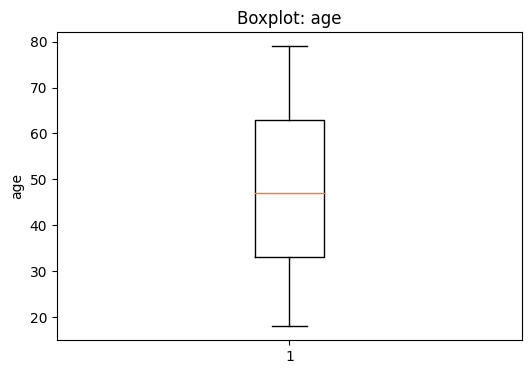

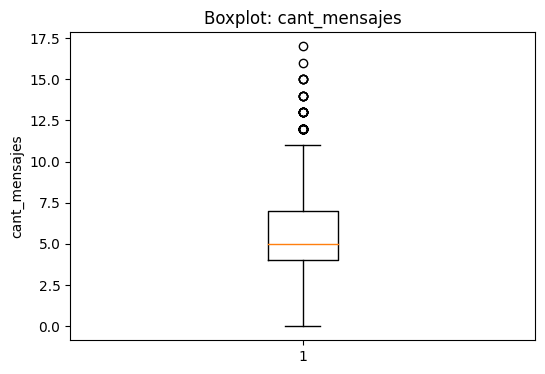

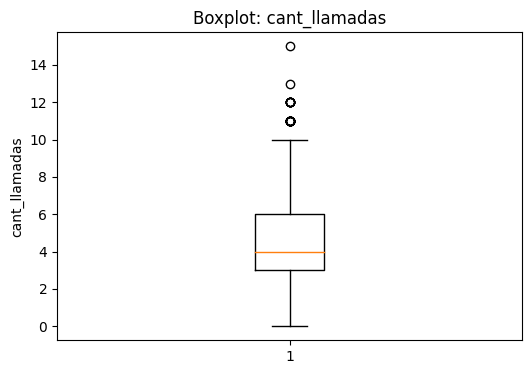

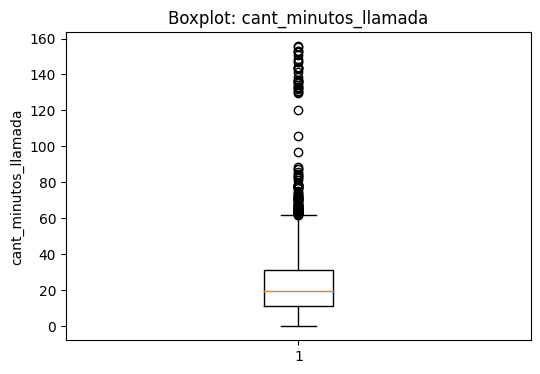

In [36]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    # Filtrar valores no nulos para cada columna que estaban causando problemas de visualización (últimas 3 columnas)
    datos_limpios = user_profile[col].dropna()
    plt.figure(figsize=(6, 4))  # Ajustar tamaño
    plt.boxplot(datos_limpios)
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()


    

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Se observan varios valores atípicos por encima de 11 mensajes, alcanzando alrededor de 17, lo que sugiere que existe un pequeño grupo de usuarios con una actividad de mensajería significativamente mayor al promedio.
- cant_llamadas: Hay valores atípicos claramente marcados en 11, 12, 13 y 15 llamadas.Estos casos representan un comportamiento inusual. Si esto fuera atención al cliente, el dato de 15 llamadas podría ser un "caso crítico" o alguien que requiere un seguimiento excepcional.
- cant_minutos_llamada: Se observa una densidad extrema de outliers a partir de los 60 minutos, hay tantos valores atípicos que forman una línea casi sólida entre los 60 y 90 minutos. Existen casos aislados que llegan hasta los 150-160 minutos.Esto indica una variabilidad enorme. Existe un grupo muy grande de usuarios o situaciones en particular que rompen totalmente el esquema "normal" de duración.

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:

    datos = user_profile[col].dropna() #Filtrado de nulos para evitar distorsiones

    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR #Solo tenemos outliers en limite superior

    print(f"\n=== Análisis de {col} ===")
    print(f"Límite superior: {limite_superior}")






=== Análisis de cant_mensajes ===
Límite superior: 11.5

=== Análisis de cant_llamadas ===
Límite superior: 10.5

=== Análisis de cant_minutos_llamada ===
Límite superior: 61.8575


In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000




💡Insights: 
- cant_mensajes: Se recomienda mantener outliers puesto que el valor máximo registrado (17) no se aleja demasiado del límite superior (11.5). Los valores que sobrepasan esta última cifra son físicamente realistas y podrían reflejar el comportamiento de un sector específico de consumidores más activos por mensajería.
  
- cant_llamadas: Al igual que en el caso anterior se recomienda mantener outliers puesto que el valor máximo registrado (15) no se aleja demasiado del límite superior (10.5). Los valores que sobrepasan esta última cifra son físicamente realistas y podrían reflejar el comportamiento de un sector específico de consumidores más activos via llamada telefónica.

  
- cant_minutos_llamada: Este caso es muy particular puesto que el valor máximo registrado (155.69) equivale casi al triple del limite superior (61.85). Esto refleja un comportamiento bastante atipico considerando la naturaleza de la columna. Si bien uno podría pensar que la causa de estas cifras tan infladas se resume a errores de captura, hasta cierto punto algunos tipo de consumidores, por ejemplo los de corte empresarial, podrían pasar horas al telefono por la naturaleza de sus actividades. Mi recomendación para esta columna sería winsorizar para no afectar las entradas del dataset y reducir la influencia de estos outliers.



---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
# Crear columna grupo_uso
def segmentacion_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if llamadas <= 5 and mensajes <= 5:
        return 'Bajo uso'
    elif llamadas <= 10 and mensajes <= 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(segmentacion_uso, axis=1)




In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Uso medio
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Bajo uso
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
def segmentacion_edad(row):
    edad = row['age']

    if edad <= 30:
        return 'Joven'

    elif edad <= 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(segmentacion_edad, axis=1)


In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,Uso medio,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,Bajo uso,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

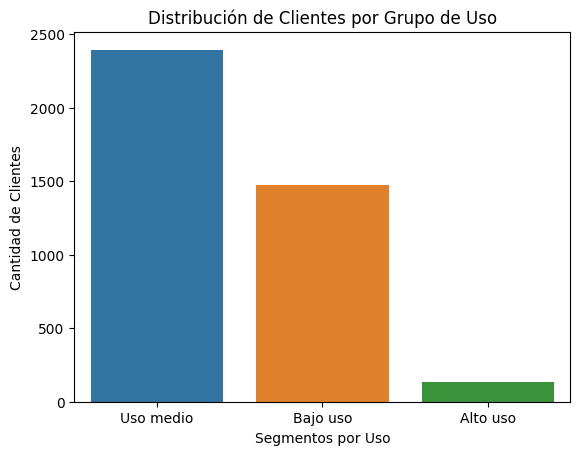

In [43]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Segmentos por Uso')
plt.ylabel('Cantidad de Clientes')
plt.show()

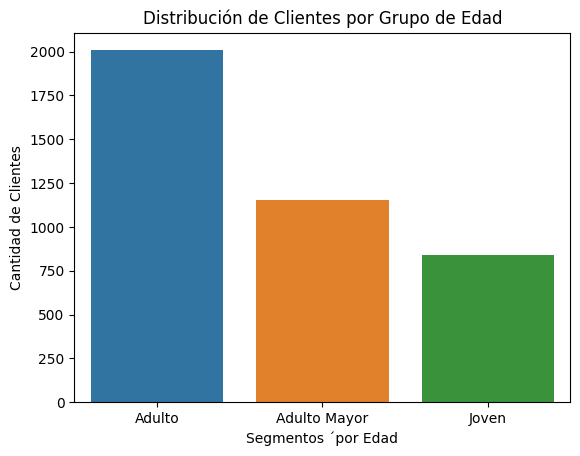

In [44]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Segmentos ´por Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron valores nulos en las columnas ‘city’ y ‘churn_date’ del **dataset users**. Los nulos en ‘city’ representaban un 11.72% de los datos de la columna, para la columna ‘churn_date’ los nulos representaban un 88.35% de la columna. En la columna ‘reg_date’ se detectaron registros de 2026 incoherentes para el contexto del análisis. En la columna ‘age’ se encontraron sentinel
s (-999) que fueron reemplazados con la mediana. En ‘city’ sentinels (?) que fueron reemplazados por valores nulos (pd.NA). Las fechas fuera de rango fueron igualmente reemplazadas por nulos (pd.NA). Respecto a 'churn_date', aunque el porcentaje de valores nulos es elevado, estos no representan un problema de calidad de datos. En este caso, los valores faltantes indican que el usuario no ha cancelado el servicio, es decir, que permanece activo. Por lo tanto, los nulos son informativos y pueden mantenerse sin modificación.
  
- En el **dataset usage** se encontraron valores faltantes en las columnas ‘date’ (0.125%), ‘duration’ (55.19%) y ‘length’ (44.74%).Se identifica un patrón estructural consistente entre las variables 'duration' y 'length' según el tipo de registro. En los registros de tipo call, la variable duration se encuentra completa, mientras que length presenta valores nulos en casi la totalidad de los casos. En contraste, en los registros de tipo text, length se encuentra completa y duration aparece mayoritariamente nula. Este comportamiento es coherente con la naturaleza de cada servicio: las llamadas registran duración, pero no longitud de caracteres, mientras que los mensajes de texto registran longitud, pero no duración. Por lo tanto, estos valores nulos responden a la estructura del modelo de datos y no representan un problema de calidad de la información.

-  Respecto a las últimas 2 columnas los valores faltantes se clasifican como valores faltantes tipo MAR (Missing At Random). En consecuencia, no se considera necesario imputarlos y se mantienen como nulos para preservar la coherencia del modelo de datos. En ´date´ los numeros se conservan ya que la cifra es mínima.

  

  **Outliers**


- Edad (age): La distribución de la variable edad no presenta valores atípicos, lo que indica consistencia y estabilidad en la composición demográfica de la base de clientes. Dado que no se identifican anomalías relevantes, no se requiere aplicar ningún tratamiento adicional, por lo que la variable puede mantenerse tal como se encuentra para los análisis posteriores.
  
- Cantidad de mensajes (cant_mensajes): Se identificaron algunos valores atípicos por encima de los 11 mensajes, con un máximo cercano a 17. No obstante, la distancia respecto al límite superior estimado (11.5) no es significativa, lo que sugiere que estos valores representan comportamientos reales de usuarios con mayor intensidad de mensajería. En consecuencia, se recomiendó conservar estos registros, ya que podrían reflejar un segmento activo relevante para el negocio.

- Cantidad de llamadas (cant_llamadas): Se observaron valores atípicos entre 11 y 15 llamadas, indicando la existencia de usuarios con niveles de actividad telefónica superiores al promedio. Sin embargo, el valor máximo (15) no se encuentra excesivamente alejado del límite superior estimado (10.5), por lo que estos casos son plausibles dentro del comportamiento del servicio. Se recomiendó mantener estos valores en el dataset para preservar información sobre patrones de uso intensivo.

- Minutos de llamada (cant_minutos_llamada): Se identificó una alta concentración de valores atípicos a partir de los 60 minutos, con extremos que alcanzan aproximadamente 155 minutos, casi tres veces el límite superior estimado (61.85). Este patrón sugiere una fuerte variabilidad en la duración de las llamadas, posiblemente asociada a perfiles de uso intensivo, como clientes empresariales. Para evitar que estos valores extremos distorsionen los análisis estadísticos, se recomiendó aplicar winsorización, reduciendo su impacto sin eliminar observaciones del conjunto de datos.


🔍 **Segmentos por Edad**
- La base de clientes actual presenta una marcada concentración en el segmento "Adulto", el cual duplica en volumen al segmento joven y representa el motor principal de ingresos de la organización. Al integrar al grupo de "Adulto Mayor", se confirma que aproximadamente el 78% de la cartera total está compuesta por perfiles de edad madura, lo que indica una sólida lealtad y un encaje de producto exitoso con este grupo demográfico de alto poder adquisitivo.
  
- El grupo "Joven" es el menos representativo, con poco menos de 850 clientes. Existe una baja penetración en las nuevas generaciones. A largo plazo, esto podría representar un riesgo de sostenibilidad si no se están captando clientes que sustituyan el ciclo de vida de los segmentos mayores. Al mismo tiempo este es el segmento con mayor potencial de crecimiento orgánico mediante estrategias de marketing digital o productos diseñados para su estilo de vida.

- En general los datos sugieren una marca percibida como "tradicional" o "madura". Si el objetivo es el crecimiento a largo plazo, se recomienda explorar por qué el segmento joven tiene una participación tan baja comparada con el resto.


📊 **Segmentos por Nivel de Uso**
- La estructura de uso revela una dependencia mayoritaria en usuarios de "Uso medio", quienes representan el volumen principal de la cartera con aproximadamente 2,400 clientes. Es preocupante observar que el segmento de "Bajo uso" (aprox. 1,480 clientes) supera por un margen de 10 a 1 al grupo de "Alto uso", el cual es apenas marginal con menos de 150 clientes. Esta configuración sugiere que, aunque existe una adopción funcional del servicio, la organización enfrenta dificultades severas para convertir a los usuarios regulares en usuarios intensivos.
  
- Un volumen tan alto de usuarios de bajo uso puede indicar una baja percepción de valor o una curva de aprendizaje compleja que ahuyenta al consumidor. Estos clientes están en la "zona de riesgo" de abandono (churn), ya que no han integrado el producto en su rutina diaria.
  


➡️ Esto sugiere la necesidad de impulsar iniciativas orientadas a equilibrar la composición demográfica de la base de clientes, incrementar la intensidad de uso del servicio y reducir el riesgo de abandono. De esta manera, se busca fortalecer la fidelización de los clientes actuales y, al mismo tiempo, potenciar la adquisición de nuevos usuarios, con el objetivo de garantizar un crecimiento sostenible del negocio en el largo plazo.


💡 **Recomendaciones**

1. **Estrategia de captación para el segmento joven:**
La baja penetración en el segmento joven representa un riesgo para la sostenibilidad de la base de clientes en el largo plazo. Se recomienda desarrollar campañas de adquisición enfocadas en canales digitales, como redes sociales, marketing de influencers y programas de referidos. Asimismo, podría evaluarse el diseño de productos o planes con beneficios alineados al estilo de vida de este segmento, como mayor enfoque en servicios digitales, comunicación ilimitada o beneficios asociados a entretenimiento y plataformas digitales.

2. **Fortalecer la propuesta de valor para clientes de alto uso:**
Dado que el segmento de alto uso es marginal, existe una oportunidad clara para incentivar un mayor consumo del servicio. Se recomienda implementar estrategias de upselling y gamificación del uso, tales como paquetes escalonados, recompensas por mayor consumo o beneficios exclusivos para usuarios intensivos. Esto permitiría aumentar el ingreso promedio por cliente (ARPU) y maximizar el valor de la base existente.


3. **Activación de clientes de bajo uso para reducir riesgo de churn:**
El alto volumen de usuarios de bajo uso indica una zona potencial de abandono. Se recomienda implementar programas de activación temprana, como campañas de educación sobre funcionalidades, recordatorios de uso, promociones temporales o beneficios por alcanzar ciertos niveles de consumo. El objetivo es integrar el servicio en la rutina diaria del usuario y aumentar su dependencia del producto.


4. **Programas de fidelización para el segmento adulto:**
El segmento adulto representa el núcleo de la base de clientes y demuestra un fuerte encaje con la propuesta de valor actual. Se recomienda reforzar la fidelización mediante programas de lealtad, beneficios exclusivos o atención personalizada, con el fin de maximizar la retención y el valor de vida del cliente (CLV) dentro de este grupo demográfico.


5. **Reposicionamiento gradual de marca para ampliar atractivo generacional:**
La distribución actual sugiere una marca percibida como tradicional. Sin perder la fortaleza en el segmento adulto, se recomienda explorar un reposicionamiento parcial de la marca que la haga más atractiva para audiencias jóvenes, mediante comunicación más dinámica, presencia digital fortalecida y alianzas con marcas o servicios relevantes para nuevas generaciones.





---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`